## **EMG Analisys with MNE and PyEmgPipeline Libraries**


In [29]:
!pip install mne pyemgpipeline matplotlib numpy scipy scikit-learn pandas pyqt5 ipympl
%matplotlib inline
#qt5 

### **1. Plot the raw_emg signal of all channels**


> #### 1.1 Data extraction and transformation

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne

# IMPORTAÇÃO E CONFIGURAÇÃO
dfEMG = pd.read_csv('data/SUBJECTS/SUBJECT02/SUBJECT02_Trial_01_EMG.csv')
sampling_rate = 440

print(dfEMG.to_numpy().shape)

# SEPARAR TRIGGERS E SINAIS
stim_data = dfEMG["Triggers"].to_numpy()                                 # Valores dos marcadores de estímulos (n_amostras, 1 canal)
emg_data = dfEMG["0"].to_numpy()                                         # Valores dos canais EMG (n_amostras, 1 canal)
print(stim_data.shape)
print(emg_data.shape)

# Objeto MNE
# TRANSFORMAR PARA O FORMATO MNE (LINHAS: CANAIS X COLUNAS: SINAIS) E JUNTAR OS MARCADORES
emg_data = emg_data * 1e-6                                               # CONVERTER DE MICROVOLTS PARA VOLTZ
data_full_mne = np.vstack([emg_data, stim_data])

# VERIFICAR FORMATO DE DADOS
print(data_full_mne.shape)
print(type(data_full_mne))


(78738, 2)
(78738,)
(78738,)
(2, 78738)
<class 'numpy.ndarray'>


> #### 1.2 Inspect raw_emg data

----DATA INFORMATION----
 <Info | 7 non-empty values
 bads: []
 ch_names: Flexor Carpi Radialis, STI 014
 chs: 1 EMG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 220.0 Hz
 meas_date: unspecified
 nchan: 2
 projs: []
 sfreq: 440.0 Hz
>

----DATA SHAPE----
 (2, 78738)
DURATION: 178.9 s


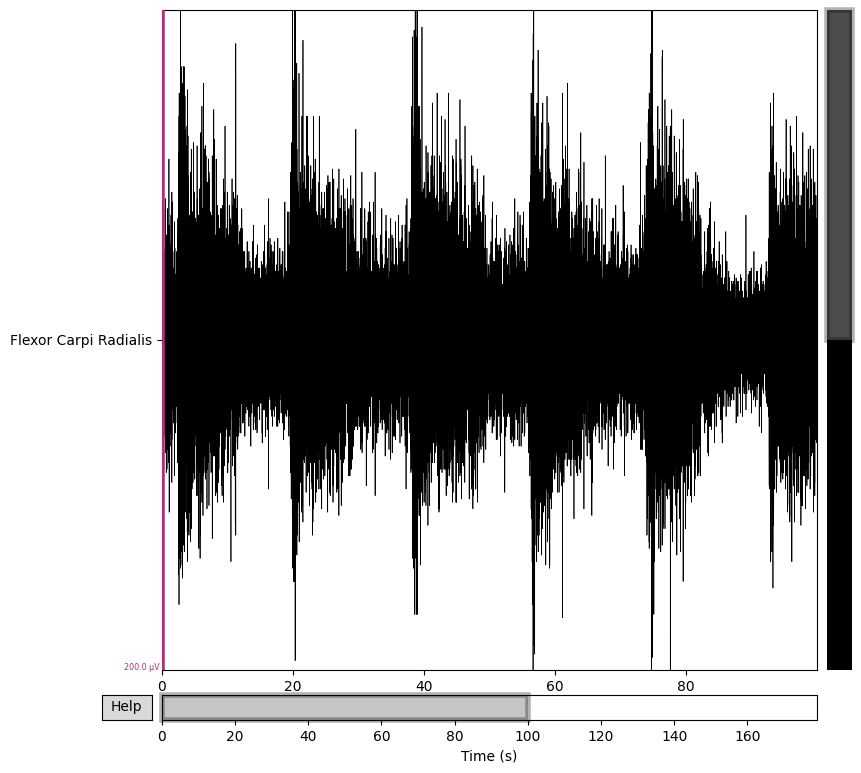

In [31]:
# CRIAR INFORMAÇÕES DOS DADOS MNE
info_full = mne.create_info(
    ch_names=["Flexor Carpi Radialis", "STI 014"],
    sfreq=sampling_rate,
    ch_types=["emg"] + ["stim"]
)

# CRIAR OBJETO DE DADOS BRUTOS
raw_emg = mne.io.RawArray(data_full_mne, info_full, verbose=False)

# VERIFICAR INFO DOS DADOS
print("----DATA INFORMATION----\n", raw_emg.info)     
print("\n----DATA SHAPE----\n",raw_emg.get_data().shape)
print(f"DURATION: {raw_emg.times[-1]:.1f} s")

# GRÁFICO
raw_emg.plot(duration=100, n_channels=1, scalings="1e-4", title="EMG bruto");

### 2. Extract and inspect Events

> #### 2.1 Create and count Events

In [32]:
# MAPEAMENTO DE MARCADORES DE EVENTOS
event_id = {
    "trial_start":      768,
    "preparation":      771,
    "exec_start":       7711,
    "exec_end":         7712,
    "trial_end":        1000,
    "session_boundary": 32766,
}

# CRIAR OBJETO DE EVENTOS
events = mne.find_events(
    raw_emg, 
    stim_channel="STI 014", 
    initial_event=True,
    consecutive=False                                           # consecutive=False -> Importante para ser compatível com o formato de marcadores
                                                                # do dataset
)

print("EVENTS SHAPE:", events.shape)                            # TABELA: (amostra onde acontece o evento, valor anterior, código do evento()
print(events[:10])

print("\n----EVENTS COUNT----")
for nome, codigo in event_id.items():
    n = (events[:, 2] == codigo).sum()
    print(f"  {nome:20s} ({codigo}): {n} ocorrências")

Finding events on: STI 014
50 events found on stim channel STI 014
Event IDs: [  768   771  1000  7711  7712 32766]
EVENTS SHAPE: (50, 3)
[[    0     0 32766]
 [   27     0   771]
 [  474     0  7711]
 [ 4431     0  7712]
 [ 6014     0  1000]
 [ 7015     0   768]
 [ 7018     0   771]
 [ 8206     0  7711]
 [12160     0  7712]
 [13744     0  1000]]

----EVENTS COUNT----
  trial_start          (768): 9 ocorrências
  preparation          (771): 9 ocorrências
  exec_start           (7711): 10 ocorrências
  exec_end             (7712): 10 ocorrências
  trial_end            (1000): 10 ocorrências
  session_boundary     (32766): 2 ocorrências


> #### 2.2 Visualize events

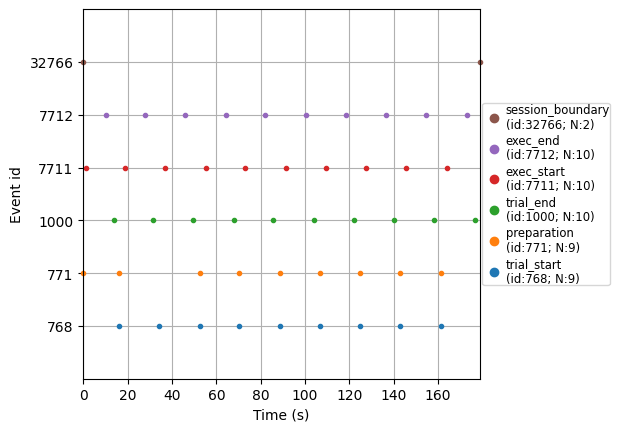

In [33]:
mne.viz.plot_events(events, sfreq=sampling_rate, event_id=event_id);

### 3. Create and inspect Epochs

In [34]:
epochs = mne.Epochs(
    raw_emg,
    events,
    event_id=event_id,
    tmin=-2,
    tmax=1,
                                                        #   referência para a calcular a média de amplitude de cada canal.
                                                        # - Visa evitar que o baseline contenha atividade de preparação motora.
    picks="emg",
    preload=True,
    verbose=False
)

# ANOTAÇÃO IMPORTANTE: talvez para o evento exec_end a janela de 
# baseline não represente um estado de repouso do participante.

print(epochs.get_data().shape)                          # → (n_trials, n_canais, n_amostras_na_janela_do_evento: 3s X 440Hz)

print("Eixo de tempo (s):", epochs.times[[0, -1]])
print("Canais:", epochs.ch_names)

# VER EPOCHS DE CADA FASE
print(epochs["trial_start"].get_data().shape)
print(epochs["preparation"].get_data().shape)
print(epochs["exec_start"].get_data().shape)
print(epochs["exec_end"].get_data().shape)
print(epochs["trial_end"].get_data().shape)
print(epochs["session_boundary"].get_data().shape)

(46, 1, 1321)
Eixo de tempo (s): [-2.  1.]
Canais: ['Flexor Carpi Radialis']
(9, 1, 1321)
(8, 1, 1321)
(9, 1, 1321)
(10, 1, 1321)
(10, 1, 1321)
(0, 1, 1321)


/tmp/ipykernel_18640/996625485.py:28: RuntimeWarning: epochs._get_data() can't run because this Epochs-object is empty. You might want to check Epochs.drop_log or Epochs.plot_drop_log() to see why epochs were dropped.
  print(epochs["session_boundary"].get_data().shape)


### 4. Preprocess signals

#### 4.1 Remove Slow Drifts and High Frequêncy Bands

No data channels found. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 20 - 2.1e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 20.00, 210.00 Hz: -6.02, -6.02 dB



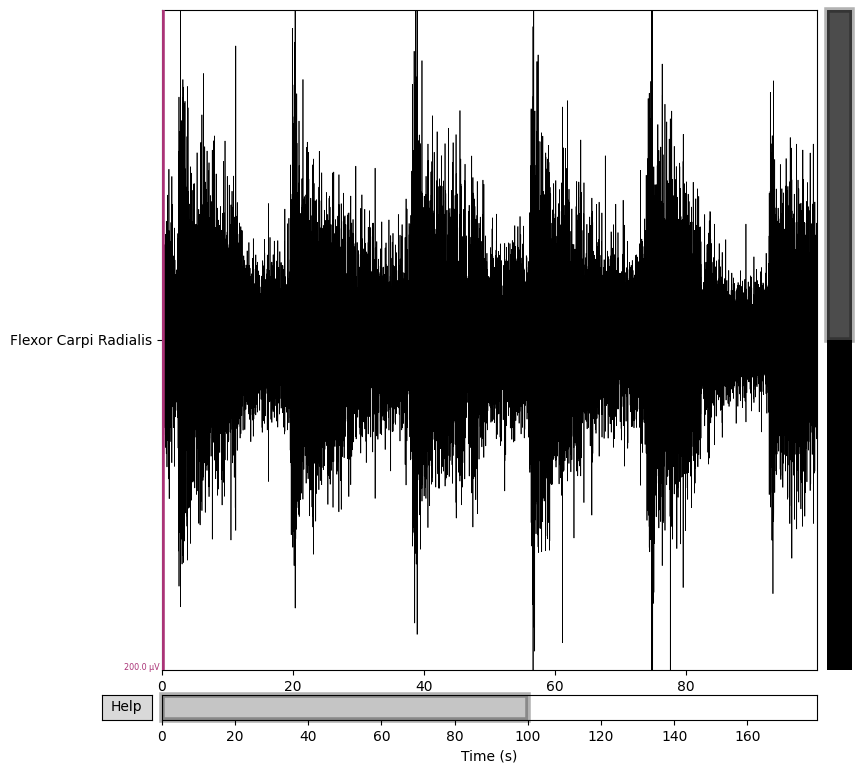

In [35]:
# FILTRO PARA REMOÇÃO DE RUÍDO DE INTERFERÊNCIA ELÉTRICA

# Obs.: O MNE só deixou filtrar abaixo de 220Hz devido ao teorema de Nyquist
# Obs.: SENIAM recomenda 20–450 Hz, mas sfreq=440 Hz limita o h_freq a ~200 Hz (Nyquist)
# Obs.: O l_freq=20.0 remove implicitamente o offset DC e artefatos de movimento abaixo de 20 Hz

filtered_emg = raw_emg.copy().filter(l_freq=20.0, h_freq=210.0, picks="emg", method="iir", iir_params=dict(order=4, ftype="butter"))
filtered_emg.plot(duration=100, n_channels=1, scalings="1e-4");

#### 4.2 Full Wave Retification

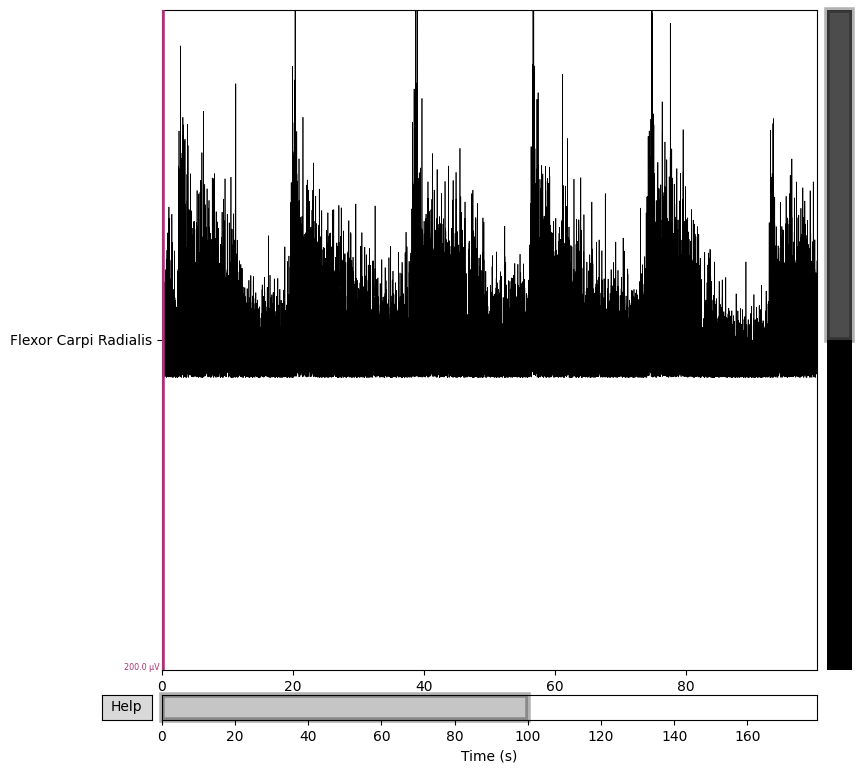

In [36]:
# APLICAR MÓDULO PARA CONSIDERAR APENAS VALORES POSITIVOS RETIFICANDO O SINAL

# Obs.: Isso deve ser feito pois apenas o sinal positivo é importante para a análise do EMG.
# Obs.: Sem retificação, a média de qualquer janela seria sempre próxima de zero independente da intensidade da contração.

filtered_emg._data[0] = np.abs(filtered_emg._data[0])
filtered_emg.plot(duration=100, n_channels=1, scalings="1e-4");

#### 4.3 Linear Envelope

No data channels found. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 10 Hz

IIR filter parameters
---------------------
Butterworth lowpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoff at 10.00 Hz: -6.02 dB



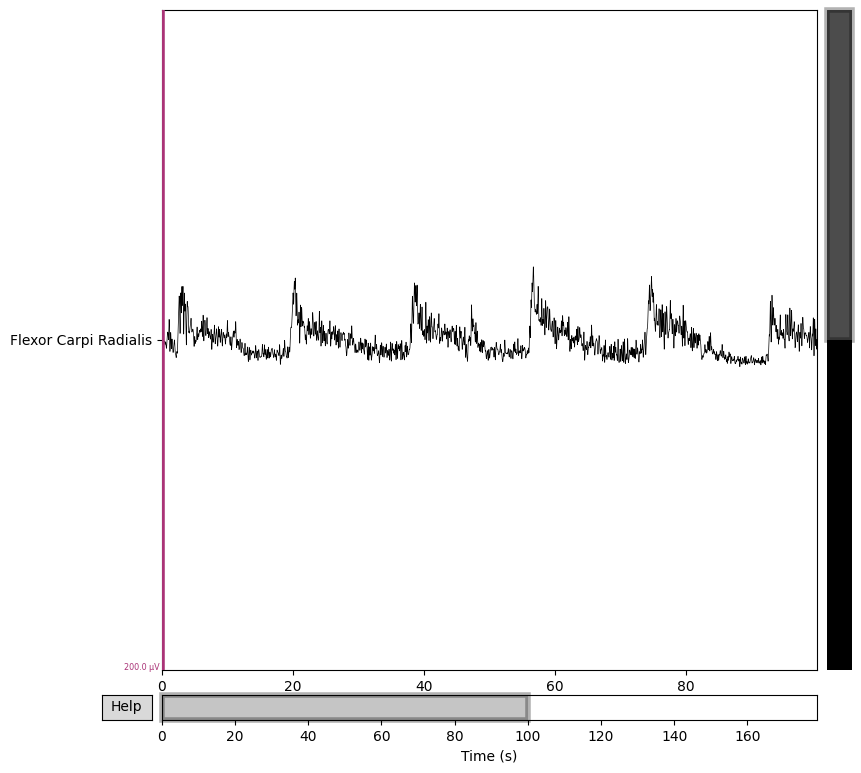

In [43]:
# OBTER CURVAS SUAVES DE REPRESENTAÇÃO DA A INTENSIDADE DA ATIVAÇÃO MUSCULAR 
# (MÉTODO ALTERNATIVO A MÉDIA QUADRÁTICA (RMS))

# Obs.: Utilizamos porque mesmo durante uma contração constante, o sinal sobe e desce rapidamente porque 
# está refletindo a soma dos potenciais de ação de muitas unidades motoras. Assim conseguimos obter uma 
# tendência geral da ativação muscular.

filtered_emg.filter(l_freq=None, h_freq=10.0, picks="emg", method="iir", iir_params=dict(order=4, ftype="butter"))
filtered_emg.plot(duration=100, n_channels=1, scalings="1e-4");

#### 4.4 Create Epochs for filtered data

In [44]:
# ÉPOCAS DOS EVENTOS COM DADOS FILTRADOS
epochs_filtered = mne.Epochs(
    filtered_emg,
    events, 
    event_id=event_id,
    tmin=-3,
    tmax=3,
    baseline=None,
    picks="emg",
    preload=True,
    verbose=False
)

### 5. Time Domain Analysis (Event Related Potential - ERP)

#### 5.1 ERP Analysis of all channels

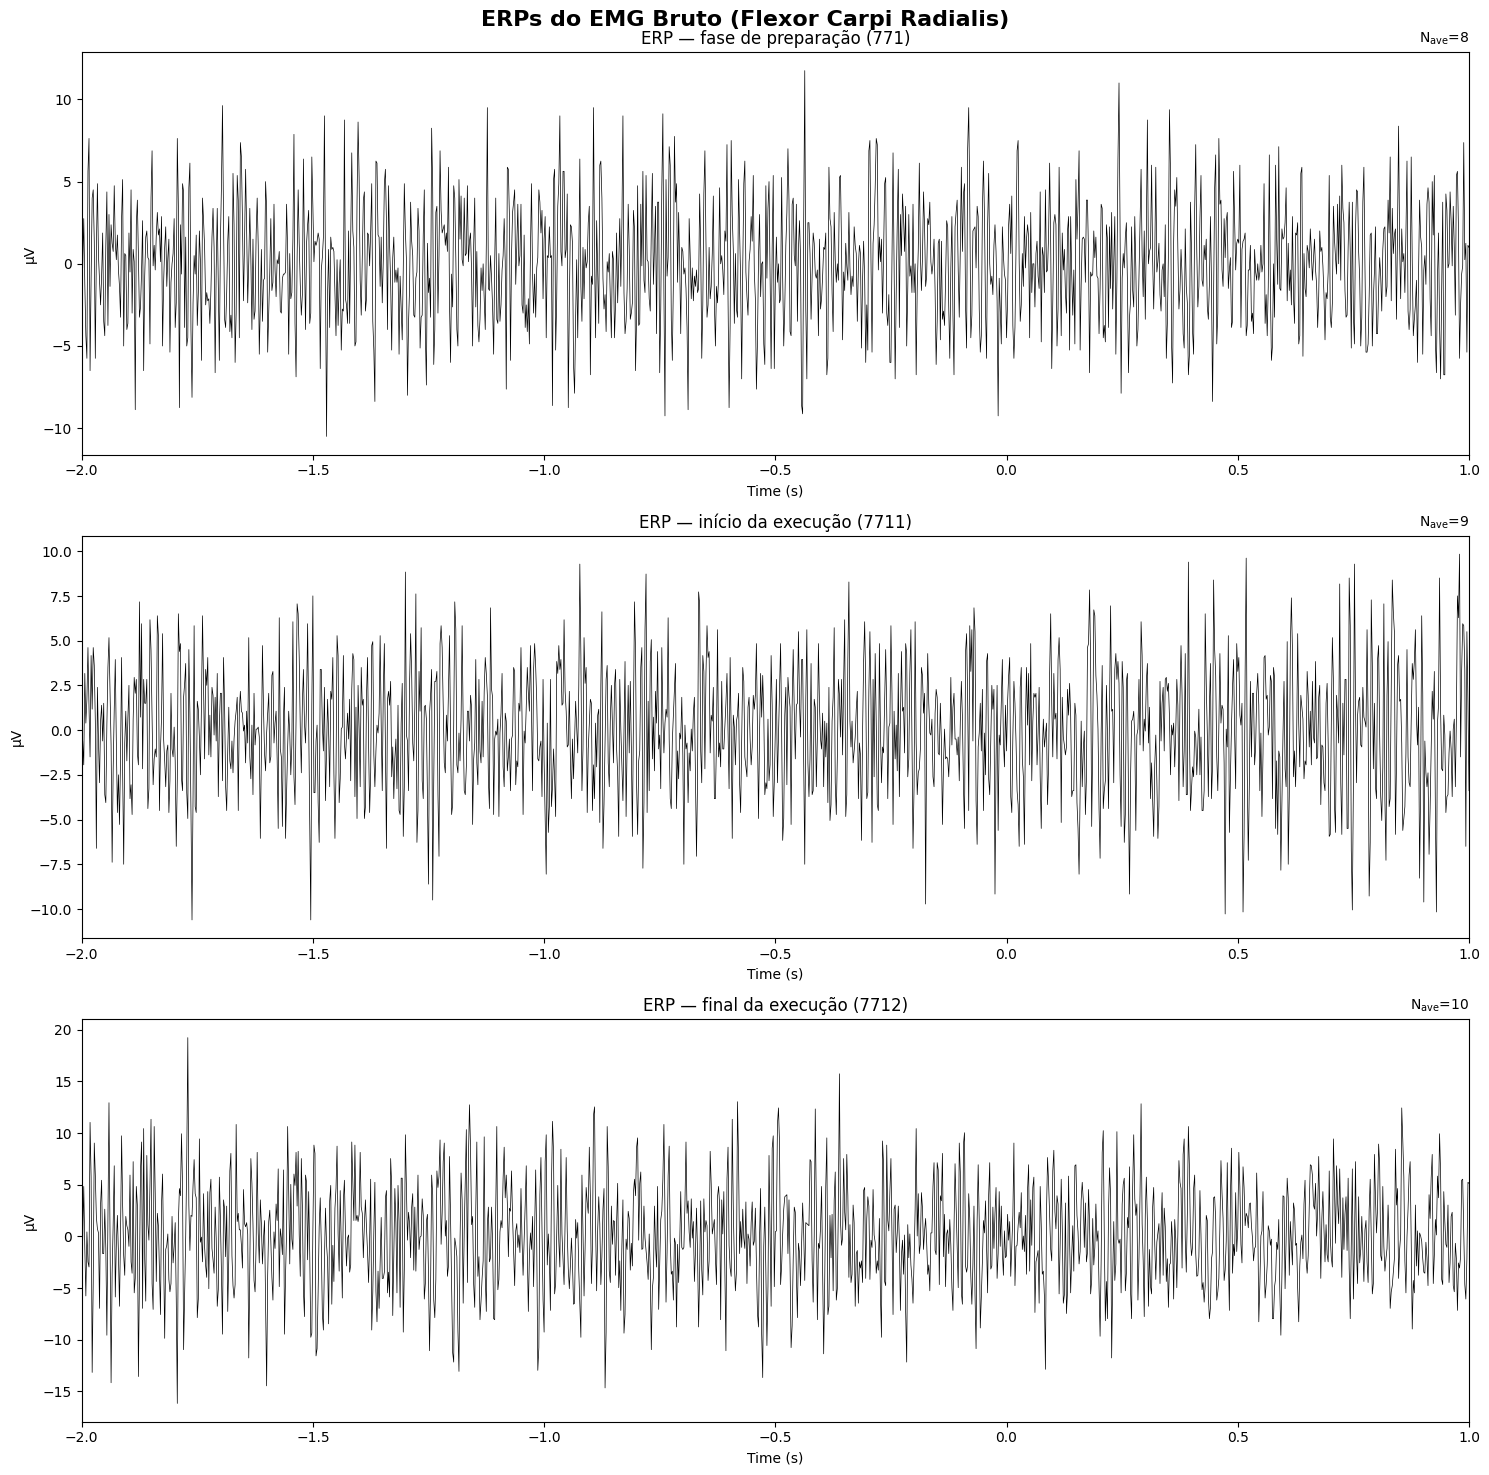

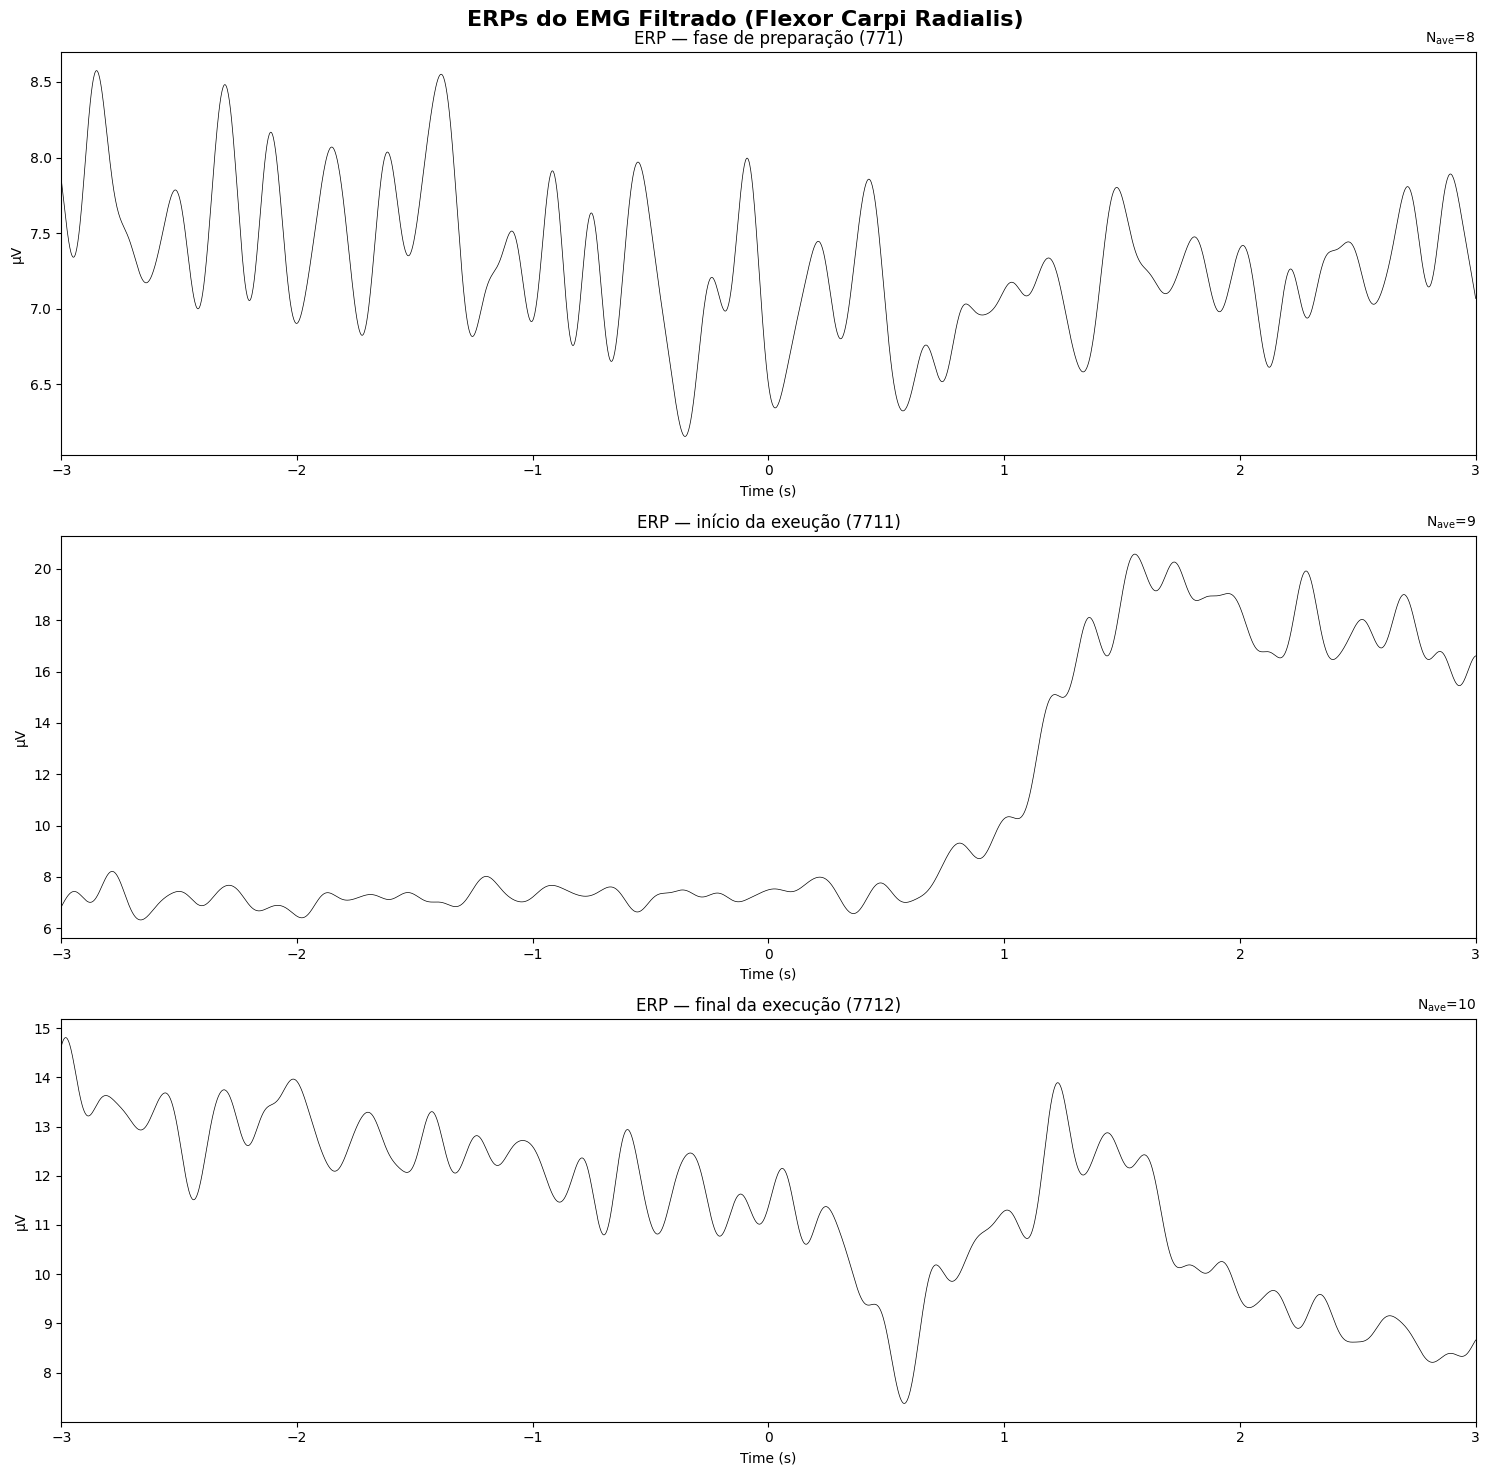

In [45]:
############# DADOS BRUTOS #############

# MÉDIA DE TODAS AS TENTATIVAS DE UM EVENTO (ERPs)
evoked_prep = epochs["preparation"].average(picks='emg')
evoked_exec_start = epochs["exec_start"].average(picks='emg')
evoked_exec_end = epochs["exec_end"].average(picks='emg')

# CONFIGURAÇÃO DE GRÁFICOS CONJUNTOS
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

evoked_prep.plot(axes=axes[0], show=False);
evoked_exec_start.plot(axes=axes[1], show=False);
evoked_exec_end.plot(axes=axes[2], show=False);

axes[0].set_title("ERP — fase de preparação (771)")
axes[1].set_title("ERP — início da execução (7711)")
axes[2].set_title("ERP — final da execução (7712)")
fig.suptitle(
    "ERPs do EMG Bruto (Flexor Carpi Radialis)",
    fontsize=16,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

############# DADOS FILTRADOS #############

# MÉDIA DE TODAS AS TENTATIVAS DE UM EVENTO (ERPs)
filtered_evoked_prep = epochs_filtered["preparation"].average(picks='emg')
filtered_evoked_exec_start = epochs_filtered["exec_start"].average(picks='emg')
filtered_evoked_exec_end = epochs_filtered["exec_end"].average(picks='emg')

# CONFIGURAÇÃO DE GRÁFICOS CONJUNTOS
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

filtered_evoked_prep.plot(axes=axes[0], show=False);
filtered_evoked_exec_start.plot(axes=axes[1], show=False);
filtered_evoked_exec_end.plot(axes=axes[2], show=False);

axes[0].set_title("ERP — fase de preparação (771)")
axes[1].set_title("ERP — início da exeução (7711)")
axes[2].set_title("ERP — final da execução (7712)")
fig.suptitle(
    "ERPs do EMG Filtrado (Flexor Carpi Radialis)",
    fontsize=16,
    fontweight="bold"
)
plt.tight_layout()
plt.show()